# Contents and why we need this lab

This lab is about implementing neural networks yourself before we start using other frameworks that hide some computation from you. It builds on the first lab, where you derived the equations for neural network forward and backward propagation and gradient descent parameter updates.

All the frameworks for deep learning you will meet from now on use automatic differentiation (autodiff), so you do not have to code the backward step yourself. In this version of this lab, you will develop your own autodif implementation.

# External source of information

[Nanograd](https://github.com/rasmusbergpalm/nanograd) is a minimalistic version of autodiff developed by [Rasmus Berg Palm](https://rasmusbergpalm.github.io) that we use for our framework.


# This notebook will follow the next steps:

1. Nanograd automatic differentiation framework
2. Finite difference method
3. Data generation
4. Defining and initializing the network
5. Forward pass
6. Training loop
7. Testing your model
8. Further extensions

# Nanograd automatic differention framework

The [Nanograd](https://github.com/rasmusbergpalm/nanograd) framework defines a class Var which both holds a value and gradient value that we can use to store the intermediate values when we apply the chain rule of differentiation.

In [1]:
from rich import print

In [2]:
# Copy and pasted from https://github.com/rasmusbergpalm/nanograd/blob/3a1bf9e9e724da813bfccf91a6f309abdade9f39/nanograd.py

from math import exp, log

class Var:
    """
    A variable which holds a float and enables gradient computations.
    """

    def __init__(self, val: float, grad_fn=lambda: []):
        assert type(val) == float #verify whether value of Var is a float variable
        self.v = val
        self.grad_fn = grad_fn 
        self.grad = 0.0

    def backprop(self, bp):
        self.grad += bp 
        for input, grad in self.grad_fn():
            input.backprop(grad * bp)

    def backward(self):
        self.backprop(1.0)
        
    ## When you use a + b and a is an instance of a class that implements __add__, Python calls a.__add__(b).
    def __add__(self: 'Var', other: 'Var') -> 'Var': #self is a instance of Var class, by doing that return a variable from Var class
        return Var(self.v + other.v, lambda: [(self, 1.0), (other, 1.0)]) #return a list of tuples that stored in the new Var variable

    def __mul__(self: 'Var', other: 'Var') -> 'Var': ##"___x___" is to define behavior of operator for custom objects
        return Var(self.v * other.v, lambda: [(self, other.v), (other, self.v)])

    def __pow__(self, power):
        assert type(power) in {float, int}, "power must be float or int"
        return Var(self.v ** power, lambda: [(self, power * self.v ** (power - 1))])

    def __neg__(self: 'Var') -> 'Var': #use definited "__mul__" as grad_fn
        return Var(-1.0) * self

    def __sub__(self: 'Var', other: 'Var') -> 'Var': #use definited  "__add__" as grad_fn
        return self + (-other)

    def __truediv__(self: 'Var', other: 'Var') -> 'Var': #because self and other connect with "*", it return with "__mul__"
        return self * other ** -1

    def __repr__(self):
        return "Var(v=%.4f, grad=%.4f)" % (self.v, self.grad)

    def relu(self):
        return Var(self.v if self.v > 0.0 else 0.0, lambda: [(self, 1.0 if self.v > 0.0 else 0.0)])

A few examples illustrate how we can use this:

In [3]:
#add
a = Var(3.0)
b = Var(5.0)
f = a-b   #if you change function "__add__" to "__aid__", the code suddenly not work.

print(f.grad_fn())
f.backward()
print(f.grad_fn())

for v in [a, b, f]:
    print(v)

[(Var(v=3.0000, grad=0.0000), 1.0), (Var(v=-5.0000, grad=0.0000), 1.0)]

[(Var(v=3.0000, grad=1.0000), 1.0), (Var(v=-5.0000, grad=1.0000), 1.0)]

Var(v=3.0000, grad=1.0000)

Var(v=5.0000, grad=-1.0000)

Var(v=-2.0000, grad=1.0000)

In [4]:
#mul
a = Var(3.0)
b = Var(5.0)
f = a*b   #if you change function "__add__" to "__aid__", the code suddenly not work.

#f.backward()
print(f.grad_fn())
print(f.grad)

for v in [a, b, f]:
    print(v)

[(Var(v=3.0000, grad=0.0000), 5.0), (Var(v=5.0000, grad=0.0000), 3.0)]

0.0

Var(v=3.0000, grad=0.0000)

Var(v=5.0000, grad=0.0000)

Var(v=15.0000, grad=0.0000)

In [5]:
##pow
a = Var(3.0)
b = 5
f = a**b

f.backward()
print(f.grad_fn)

for v in [a, b, f]:
    print(v)

<function Var.__pow__.<locals>.<lambda> at 0x7fa9ed4342c0>

Var(v=3.0000, grad=405.0000)

5

Var(v=243.0000, grad=1.0000)

In [6]:
a = Var(3.0)
b = Var(5.0)
f = a/b   #if you change function "__add__" to "__aid__", the code suddenly not work.

f.backward()
print(f.grad_fn)

for v in [a, b, f]:
    print(v)

<function Var.__mul__.<locals>.<lambda> at 0x7fa9ed434180>

Var(v=3.0000, grad=0.2000)

Var(v=5.0000, grad=-0.1200)

Var(v=0.6000, grad=1.0000)

In [7]:
a = Var(3.0)
b = Var(5.0)
c = a * b
d = Var(9.0)
e = a * d
f = c + e

f.backward()
print(e.grad_fn())

for v in [a, b, c, d, e, f]:
    print(v)

[(Var(v=3.0000, grad=14.0000), 9.0), (Var(v=9.0000, grad=3.0000), 3.0)]

Var(v=3.0000, grad=14.0000)

Var(v=5.0000, grad=3.0000)

Var(v=15.0000, grad=1.0000)

Var(v=9.0000, grad=3.0000)

Var(v=27.0000, grad=1.0000)

Var(v=42.0000, grad=1.0000)

## Exercise a) What is being calculated?

Explain briefly the output of the code? What is the expression we differentiate and with respect to what variables?

The output of the code using function "__repr__" which it returns an object of a string by detecting "print()" function. As the function "__repr__" defining, it returned the value of this variable during forward feeding and its gradient through backward processing. The idea of gradient graph is to store each gradient during forward pass and use chain rule to calculate gradient of children layer step by step (from the last layer to the first layer). 

It is important to know that:
- each variable it created will become an object from class Var
- each object in class Var only know its own value and who is their children. They don't know who is their father and who is their grand-children.

#### Value during forward feeding
$a$ is equal to $a$ itself, $b$ is equal to $b$ itself (so as $d$). $c$ in forward feeding equal to $a$ multiple b. $e$ equal to $a$ multiple $b$

#### Gradient through backward processing

$$
\begin{align}
grad\_f &= \frac{\partial f}{\partial f} &= 1  \quad \text{Equal to itself} \\
grad\_c &= \frac{\partial f}{\partial f} \frac{\partial f}{\partial c} &= 1 * \frac{\partial (c+e)}{\partial c} &=1 \\
grad\_e &= \frac{\partial f}{\partial f} \frac{\partial f}{\partial e} &= 1 * \frac{\partial (c+e)}{\partial e} &= 1   \\
grad\_d &= \frac{\partial f}{\partial f} \frac{\partial f}{\partial e} \frac{\partial e}{\partial d} &= 1*1*\frac{\partial (a*d)}{\partial d} &= 3 \\
grad\_b &= \frac{\partial f}{\partial f} \frac{\partial f}{\partial c} \frac{\partial c}{\partial b} &= 1*1*\frac{\partial (a*b)}{\partial b}  &= 3  \\
grad\_a &= \frac{\partial f}{\partial f} \frac{\partial f}{\partial c} \frac{\partial c}{\partial a}  + \frac{\partial f}{\partial f} \frac{\partial f}{\partial e} \frac{\partial e}{\partial a} &= 1*1*\frac{\partial (a*b)}{\partial a} + 1*1*\frac{\partial (a*d)}{\partial a} &= 5 + 9 = 14 \\ 
\end{align}
$$


## Exercise b) How does the backward function work?

You need to understand how the backward function calculates the gradients. We can use the two examples above to help with that.

Go through the following four steps and answer the questions on the way:

1. We represent the two expressions as graphs as shown below. Fill in the missing expressions for the different derivatives.

2. In the remainder, consider the first expression. Make a schematic of the data structure generated when we define the expression for f (e.g., write a list of which objects are created and the corresponding values of their member variables).

3. Then execute the backward function by hand to convince yourself that it indeed calculates the gradients with respect to the variables.

4. Write down the sequence of calls to backprop.

## Answer: 
1. Consider the first expression we are using $f = a*b$

2. Explain the code line by line:
- $a = Var(3.0)$ and $b = Var(5.0)$: 
    - create an instance of class $Var$ and have only the value and initialized gradient value equal to 1.

    In terms of $a$ variable
        $$
        \begin{align}
        a.v &= 3 \\
        a.grad\_fn() &= [\quad] \\
        a.grad &= 0.0
        \end{align}
        $$

    In terms of $b$ variable
        $$
        \begin{align}
        b.v &= 5 \\
        b.grad\_fn() &= [\quad] \\
        b.grad &= 0.0
        \end{align}
        $$
- $f = a*b$:
    - Python magic method detecting in-built function "__mul__" when $f = a * b$.
    - Through this function, $a$ and $b$ does not change but a new instance of $Var$ specifying for f is created
    
    In terms of $f$ variable
        $$
        \begin{align}
        f.v &= 15 \\
        f.grad\_fn() &= [(Var(v=3.0000, grad=0.0000), 5.0), (Var(v=5.0000, grad=0.0000), 3.0)] \\
        f.grad &= 0.0
        \end{align}
        $$
    $f.grad\_fn()$ is a list object that contain two tuple, each tuple have two variable, the first one position store a $Var$ instance that crate $f$ with $v$ illustrating value and the $grad$ illustrating current gradient, the second position store the gradient for backward propagation in this operator. For the product of two parameters, their derivatives are values of each other. However, without using $f.backward()$ means the forward pass has not finished. We don't know what is true gradient for $a$ and $b$ in terms of final output that might be $f$ or other. For back propagation, the gradient of each layer is only related to its previous layer ($L+1$).
   

Question 3: Backward propagation

1. ``` f.backward() --> f.backprop(1.0) ```
    - initiating "backprop" function
    - 1.0 is the value for $\frac{\partial f}{\partial f}$
2. ```backprop(f,1.0) --> f.grad = f.grad + 1```
    - $f.grad = f.grad + 1$ is calculating $\frac{\partial f}{\partial f}$, it equals to itself.
    - Now, ```f.grad_fn() = [(Var(v=3.0000, grad=1.0000), 5.0), (Var(v=5.0000, grad=1.0000), 3.0)]```
3. ```for input,grad in self.grad_fn():```
    - input have ```(Var(v=3.0000, grad=1.0000)``` (correspond to $a$) and ```(Var(v=5.0000, grad=1.0000)``` (correspond to $b$)
    - grad have 3 and 5 accordingly
4. ```input.backprop(grad*bp)```
    - for the first argument correspond to $a$, ``` a.backprop(5*1)```
    (PS. Remember the gradient value for the actual $a$ has not change) 
    - for the second argument correspond to $b$, ``` b.backprop(3*1)```
5. Then recursively use function ```backprop(self,bp)```
    - for ``` a.backprop(5*1)```, Then ```a.grad = 5```, the gradient for $a$ now is 5.
    - for ``` b.backprop(3*1)```, Then ```b.grad = 3```, the gradient for $b$ now is 3.
    - Because both ```a.grad_fn()``` and ```b.grad_fn()``` are ```[]```. So the program stop. 

Question 4:
```f.backward() --> f.backprop(1) --> a.backprop(5) & b.backprop(3)```


In [8]:
# If you have not installed networkx and matplotlib, you can install them by running
# !pip install networkx matplotlib

import networkx as nx
import matplotlib.pyplot as plt

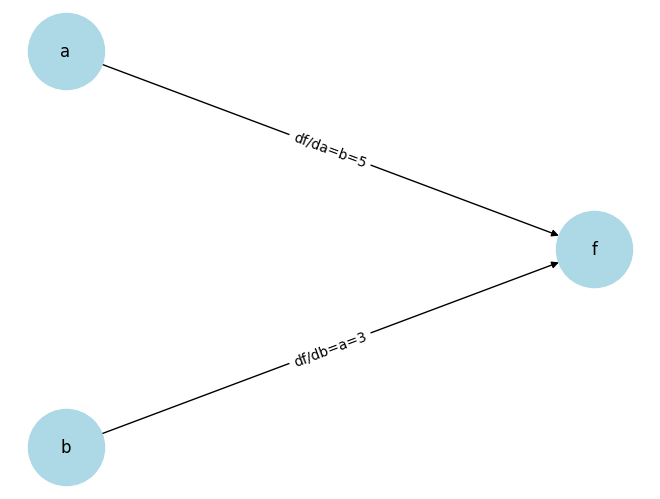

<Figure size 640x480 with 0 Axes>

In [9]:
# Create a directed graph
G = nx.DiGraph()

# Add edges with labels
G.add_edge('a', 'f', label='df/da=b=5')
G.add_edge('b', 'f', label='df/db=a=3')

# Manually define positions for a tree layout
pos = {
    'a': (0, 1),
    'b': (0, -1),
    'f': (1, 0),
}
# Draw the graph nodes and edges
nx.draw(G, pos, with_labels=True, node_shape='o', node_size=3000, node_color='lightblue', arrows=True)

# Draw edge labels
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# Show the plot
plt.show()
plt.savefig("Question2_b_1.png", format="png", dpi=300)

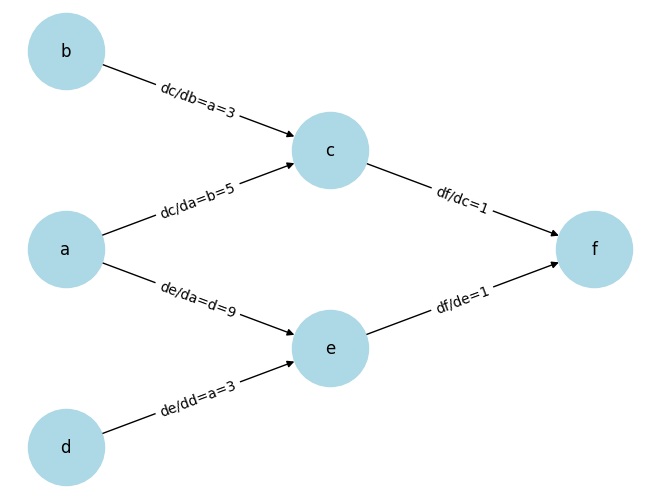

<Figure size 640x480 with 0 Axes>

In [10]:
# Create a directed graph
G = nx.DiGraph()

# Add edges with labels
G.add_edge('a', 'c', label='dc/da=b=5')
G.add_edge('b', 'c', label='dc/db=a=3')
G.add_edge('a', 'e', label='de/da=d=9')
G.add_edge('d', 'e', label='de/dd=a=3')
G.add_edge('c', 'f', label='df/dc=1')
G.add_edge('e', 'f', label='df/de=1')

# Manually define positions for a tree layout
pos = {
    'a': (0, 0),
    'b': (0, 2),
    'c': (1, 1),
    'd': (0, -2),
    'e': (1, -1),
    'f': (2, 0)
}

# Draw the graph nodes and edges
nx.draw(G, pos, with_labels=True, node_shape='o', node_size=3000, node_color='lightblue', arrows=True)

# Draw edge labels
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# Show the plot
plt.show()
plt.savefig("Question2_b_2.png", format="png", dpi=300)


## Exercise c) What happens if we run backward again?

Try to execute the code below. Explain what happens.

In [11]:
a = Var(3.0)
b = Var(5.0)
c = a * b
d = Var(9.0)
e = a * d
f = c + e

f.backward()

for v in [a, b, c, d, e, f]:
    print(v)

Var(v=3.0000, grad=14.0000)

Var(v=5.0000, grad=3.0000)

Var(v=15.0000, grad=1.0000)

Var(v=9.0000, grad=3.0000)

Var(v=27.0000, grad=1.0000)

Var(v=42.0000, grad=1.0000)

In [12]:
f.backprop(-4)
for v in [a, b, c, d, e, f]:
    print(v)

Var(v=3.0000, grad=-42.0000)

Var(v=5.0000, grad=-9.0000)

Var(v=15.0000, grad=-3.0000)

Var(v=9.0000, grad=-9.0000)

Var(v=27.0000, grad=-3.0000)

Var(v=42.0000, grad=-3.0000)

In [13]:
f.backward()

for v in [a, b, c, d, e, f]:
    print(v)

Var(v=3.0000, grad=-28.0000)

Var(v=5.0000, grad=-6.0000)

Var(v=15.0000, grad=-2.0000)

Var(v=9.0000, grad=-6.0000)

Var(v=27.0000, grad=-2.0000)

Var(v=42.0000, grad=-2.0000)

In [14]:
## Because the new a value change here does not change the creation of f, then it does not change gradient 
a = Var(2.0)
f.backward()

for v in [a, b, c, d, e, f]:
    print(v)

Var(v=2.0000, grad=0.0000)

Var(v=5.0000, grad=-3.0000)

Var(v=15.0000, grad=-1.0000)

Var(v=9.0000, grad=-3.0000)

Var(v=27.0000, grad=-1.0000)

Var(v=42.0000, grad=-1.0000)

#### Explanation
1. **The first function is to update each layer appropriately**
The ``` self.grad += bp ``` in the code cause the gradient change for each variable.

Take a look at $a$ variable:
- the change of gradient in $a$ variable depend on $c$ and $e$
    $$
    grad\_a = \frac{\partial f}{\partial f} \frac{\partial f}{\partial c} \frac{\partial c}{\partial a}  + \frac{\partial f}{\partial f} \frac{\partial f}{\partial e} \frac{\partial e}{\partial a}
    $$
This explained in some layer, the change of node is not only depended on only one node from previous layer ($L+1$)

2. **The second function is to update each weight from the weight of the output layer.**
- In this example, the second $backward()$ function only add the previous gradient to the current gradient.
- But we can use ```f.backprop(bp)``` by specifying ```bp``` as gradient change for the last value $f$ or last layer $f$.
This is the way to update its ```grad_fn```'s ```grad_fn```/ its children's layer by only knowing what is the change in the last layer. 


## Exercise d) Zero gradient

We can zero the gradient by backpropagating a -1.0 as is shown in the example below. (If you have run backward multiple time then you also have to run the cell below an equal amount of times.) Explain what is going on.

In [15]:
a = Var(3.0)
b = Var(5.0)
c = a * b
d = Var(9.0)
e = a * d
f = c + e

f.backward()

for v in [a, b, c, d, e, f]:
    print(v)

Var(v=3.0000, grad=14.0000)

Var(v=5.0000, grad=3.0000)

Var(v=15.0000, grad=1.0000)

Var(v=9.0000, grad=3.0000)

Var(v=27.0000, grad=1.0000)

Var(v=42.0000, grad=1.0000)

In [16]:
a = Var(2.0)

for v in [a, b, c, d, e, f]:
    print(v)


Var(v=2.0000, grad=0.0000)

Var(v=5.0000, grad=3.0000)

Var(v=15.0000, grad=1.0000)

Var(v=9.0000, grad=3.0000)

Var(v=27.0000, grad=1.0000)

Var(v=42.0000, grad=1.0000)

#### Explanation:
$a$ is assigned with a new "Var" instance. In the code, creating a new instance always have its ```grad``` equal to zero. It overrided the gradient calculated by ```f.backward()```.

In [17]:
f.backprop(-1.0)

for v in [a, b, c, d, e, f]:
    print(v)

Var(v=2.0000, grad=0.0000)

Var(v=5.0000, grad=0.0000)

Var(v=15.0000, grad=0.0000)

Var(v=9.0000, grad=0.0000)

Var(v=27.0000, grad=0.0000)

Var(v=42.0000, grad=0.0000)

#### Explanation:
If the last gradient is equal to 0: $\frac{\partial f}{\partial f} = 0$, the rest of gradients all using $\frac{\partial f}{\partial f}$ as their first argument and their gradient all become 0.

## Exercise e) Test correctness of derivatives with the finite difference method

Write a small function that uses [the finite difference method](https://en.wikipedia.org/wiki/Finite_difference_method) to numerically test that backpropation implementation is working. In short we will use
$$
\frac{\partial f(a)}{\partial a} \approx \frac{f(a+da)-f(a)}{da}
$$
for $da \ll 1$.

As an example, we could approximate the derivative of the function $f(a)=a^2$ in e.g. the value $a=4$ using the finite difference method. This amounts to inserting the relevant values and approximating the gradient $f'(4)$ with the fraction above.


In [18]:
# f function - try to change the code to test other types of functions as well (such as different polynomials etc.)
class MethodClass:
    def apply_method(self, method_name, *args, **kwargs):
        # Dynamically get the method by name
        method = getattr(self, method_name, None)
        if not method:
            raise ValueError(f"Method '{method_name}' does not exist.")
        # Call the method with provided arguments
        return method(*args, **kwargs)
    
    #using nanograd to calculate the gradient
    def multiple(self, a):
        a = Var(a)
        b = Var(5.0)
        f = a * b
        f.backward()
        return a, b, f
    #using nanograd to calculate the gradient
    def random_function(self, a):
        a = Var(a)
        b = Var(5.0)
        f = a**2 + b + b * a + b / a + a-b + a**2
        f.backward()
        return a, b, f
    
    #print the results 
    def print_tuple(self, input_tuple):
        # Ensure the input is a tuple
        if not isinstance(input_tuple, tuple):
            raise ValueError("Input must be a tuple.")
        # Print each element in the tuple
        for index,element in enumerate(input_tuple):
            print(f"{element}")
    
    def finite_difference(self, method_name, a=5.0, da=1e-10):
        """
        Computes the finite difference for the specified method.

        Input:
        method_name:   The name of the method to compute the derivative for (str)
        a:             The input value                                     (float)
        da:            The finite difference increment                    (float)

        Output:
        finite_difference: numerical approximation to the derivative       (float)
        """
        # Compute f(a + da) and f(a) dynamically using apply_method
        fa_da = self.apply_method(method_name, a + da)[2].v  # Access result value
        fa = self.apply_method(method_name, a)[2].v    # Access result value

        # Compute finite difference
        finite_difference = (fa_da - fa) / da

        return finite_difference
    

In [19]:
method_1 = MethodClass()
results = method_1.apply_method("random_function",5.0)
print(method_1.print_tuple(results))
print(method_1.finite_difference("random_function", 5.0)) 

Var(v=5.0000, grad=25.8000)

Var(v=5.0000, grad=5.2000)

Var(v=81.0000, grad=1.0000)

None

25.79994884399639

# Create an artificial dataset to play with

We create a non-linear 1d regression task. The generator supports various noise levels and it creates train, validation and test sets. You can modify it yourself if you want more or less challenging tasks.

In [49]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## understand how they generate different data

In [50]:
X = np.random.multivariate_normal(np.zeros(3), 0.1*np.eye(3), size = 20)
y = np.sin(X[:,0]) - 5*(X[:,1]**2) + 0.5*X[:,2]
data_set = np.vstack((X.T,y)).T #the last column contain y and the rest columns are all x in different dimensions.
train, validation, test = np.split(data_set, [int(0.35*20), int(0.7*20)], axis=0)


### How they split the data?
The data_set will be split into three sub-arrays:
- First Sub-array: From the start of data_set to the row at the 35% mark (int(0.35 * n_samples)).
- Second Sub-array: From the 35% to the 70% mark (int(0.7 * n_samples)).
- Third Sub-array: From the 70% to the end of data_set.

In [51]:
def data_generator(noise=0.1, n_samples=300, D1=True):
    # Create covariates and response variable
    if D1:
        X = np.linspace(-3, 3, num=n_samples).reshape(-1,1) # 1-D
        np.random.shuffle(X)
        y = np.random.normal((0.5*np.sin(X[:,0]*3) + X[:,0]), noise) # 1-D with trend
    else:
        X = np.random.multivariate_normal(np.zeros(3), noise*np.eye(3), size = n_samples) # 3-D
        np.random.shuffle(X)
        y = np.sin(X[:,0]) - 5*(X[:,1]**2) + 0.5*X[:,2] # 3-D

    # Stack them together vertically to split data set
    data_set = np.vstack((X.T,y)).T #the last column contain y and the rest columns are all x in different dimensions.
    
    #axis=0, split along the rows
    train, validation, test = np.split(data_set, [int(0.35*n_samples), int(0.7*n_samples)], axis=0)
    

    # Standardization of the data, remember we do the standardization with the training set mean and standard deviation
    train_mu = np.mean(train, axis=0) #axis=0, do to every row == each column's all the data's mean
    train_sigma = np.std(train, axis=0)

    train = (train-train_mu)/train_sigma
    validation = (validation-train_mu)/train_sigma
    test = (test-train_mu)/train_sigma

    x_train, x_validation, x_test = train[:,:-1], validation[:,:-1], test[:,:-1]
    y_train, y_validation, y_test = train[:,-1], validation[:,-1], test[:,-1]

    return x_train, y_train,  x_validation, y_validation, x_test, y_test

#### Why only using training_mu and training_sigma for standardization
- information leakage: Information leakage occurs when data from the test set influences the training process, leading to overly optimistic performance estimates. Just avoid test set contribute to these statistics
    -   Using the test set's mean and standard deviation (directly or indirectly) biases the evaluation process because the test set is no longer "unseen."
    - To accurately measure how well the model generalizes, the test data must remain untouched and treated as unseen.
- Consistency and during development:
    -  The standardization applied during training must match what will be applied to new, unseen data in production.
    - By standardizing with the training set mean and standard deviation, we ensure that the model behaves consistently with how it was trained when making predictions on new data.

In [52]:
D1 = True
x_train, y_train,  x_validation, y_validation, x_test, y_test = data_generator(noise=0.5, D1=D1)

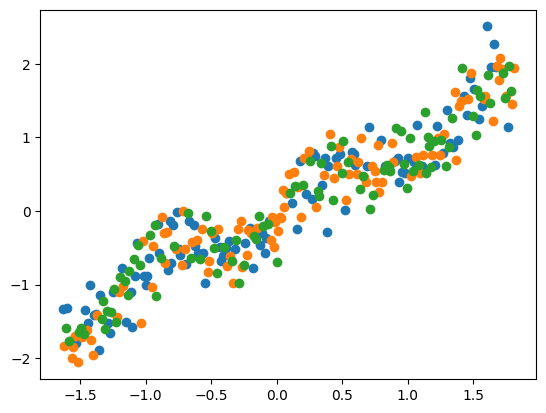

In [53]:
if D1:
    plt.scatter(x_train[:,0], y_train);
    plt.scatter(x_validation[:,0], y_validation);
    plt.scatter(x_test[:,0], y_test);
else:
    plt.scatter(x_train[:,1], y_train);
    plt.scatter(x_validation[:,1], y_validation);
    plt.scatter(x_test[:,1], y_test);
plt.show()

In [54]:
print(x_train.shape[0])
print(x_validation.shape[0])
print(x_test.shape[0])


105
105
90


In [55]:
# convert from nparray to Var
def nparray_to_Var(x):
  if x.ndim==1:
    y = [[Var(float(x[i]))] for i in range(x.shape[0])] # always work with list of list
  else:
    y = [[Var(float(x[i,j])) for j in range(x.shape[1])] for i in range(x.shape[0])]
  return y

x_train = nparray_to_Var(x_train)
y_train = nparray_to_Var(y_train)
x_validation = nparray_to_Var(x_validation)
y_validation = nparray_to_Var(y_validation)
x_test = nparray_to_Var(x_test)
y_test = nparray_to_Var(y_test)


In [56]:
x_train

[[Var(v=0.3478, grad=0.0000)],
 [Var(v=-0.0550, grad=0.0000)],
 [Var(v=-0.1816, grad=0.0000)],
 [Var(v=-0.5500, grad=0.0000)],
 [Var(v=-0.8032, grad=0.0000)],
 [Var(v=-1.2521, grad=0.0000)],
 [Var(v=1.0730, grad=0.0000)],
 [Var(v=0.9349, grad=0.0000)],
 [Var(v=1.3493, grad=0.0000)],
 [Var(v=0.9809, grad=0.0000)],
 [Var(v=-0.1126, grad=0.0000)],
 [Var(v=0.9234, grad=0.0000)],
 [Var(v=1.6600, grad=0.0000)],
 [Var(v=0.8313, grad=0.0000)],
 [Var(v=0.1752, grad=0.0000)],
 [Var(v=-0.5960, grad=0.0000)],
 [Var(v=-0.8953, grad=0.0000)],
 [Var(v=-0.7342, grad=0.0000)],
 [Var(v=-1.5284, grad=0.0000)],
 [Var(v=-0.7457, grad=0.0000)],
 [Var(v=-0.0781, grad=0.0000)],
 [Var(v=1.1075, grad=0.0000)],
 [Var(v=-1.2867, grad=0.0000)],
 [Var(v=-0.7917, grad=0.0000)],
 [Var(v=0.7047, grad=0.0000)],
 [Var(v=-0.9874, grad=0.0000)],
 [Var(v=-1.0104, grad=0.0000)],
 [Var(v=0.5896, grad=0.0000)],
 [Var(v=1.6025, grad=0.0000)],
 [Var(v=-0.4349, grad=0.0000)],
 [Var(v=-0.6306, grad=0.0000)],
 [Var(v=0.7968, grad=

# Defining and initializing the network

The steps to create a feed forward neural network are the following:

1. **Number of hidden layer and hidden units**. We have to define the number of hidden units in each layer. The number of features in X and the output dimensionality (the size of Y) are given but the numbers in between are set by the researcher. Remember that for each unit in each layer beside in the input has a bias term.
2. **Activation functions** for each hidden layer. Each hidden layer in your list must have an activation function (it can also be the linear activation which is equivalent to identity function). The power of neural networks comes from non-linear activation functions that learn representations (features) from the data allowing us to learn from it.
3. **Parameter initialization**. We will initialize the weights to have random values. This is done in practice by drawing pseudo random numbers from a Gaussian or uniform distribution. It turns out that for deeper models we have to be careful about how we scale the random numbers. This will be the topic of the exercise below. For now we will just use unit variance Gaussians. (standard normal distribution)

In order to make life easier for ourselves we define a DenseLayer class that takes care of initialization and the forward pass. We can also extend it later with print and advanced initialization capabilities. For the latter we have introduced a Initializer class.

Note that we use Sequence in the code below. A Sequence is an ordered list. This means the order we insert and access items are the same.

In [2]:
class Initializer:

  def init_weights(self, n_in, n_out):
    raise NotImplementedError

  def init_bias(self, n_out):
    raise NotImplementedError


In [3]:
import random

class NormalInitializer(Initializer):

  def __init__(self, mean=0, std=0.1):
    self.mean = mean
    self.std = std
   
  ##number of input and number of output 
  def init_weights(self, n_in, n_out):
    return [[Var(random.gauss(self.mean, self.std)) for _ in range(n_out)] for _ in range(n_in)]

  def init_bias(self, n_out):
    return [Var(0.0) for _ in range(n_out)]
  
  
class ConstantInitializer(Initializer):

  def __init__(self, weight=1.0, bias=0.0):
    self.weight = weight
    self.bias = bias

  def init_weights(self, n_in, n_out):
    return [[Var(self.weight) for _ in range(n_out)] for _ in range(n_in)]

  def init_bias(self, n_out):
    return [Var(self.bias) for _ in range(n_out)]

In [30]:
# initializer = NormalInitializer()
# initializer.init_weights(5,10)
# initializer.init_bias(10)

#### Why import Sequence
Key Features of Sequence:
- Supports indexing (obj[index]).
- Supports iteration (for x in obj).
- Supports len(obj).
    - Includes methods like:
        - "\_\_getitem\_\_" (indexing).
        - "\_\_len\_\_" (length of the sequence).

In [6]:

from typing import Sequence
import inspect

class DenseLayer:
    def __init__(self, n_in: int, n_out: int, act_fn, initializer = NormalInitializer()):
        self.weights = initializer.init_weights(n_in, n_out)
        self.bias = initializer.init_bias(n_out)
        self.act_fn = act_fn

    # def __repr__(self):
    #     return 'Weights: ' + repr(self.weights) + ' Biases: ' + repr(self.bias)
    
# -> Sequence[Var] is the type-hint in python to indicate the return type 
    def parameters(self) -> Sequence[Var]: 
      params = []
      for r in self.weights:
        params += r

      return params + self.bias
    
    def __repr__(self):
        weight_info = "[" + ", ".join([str(weight) for weight in self.weights[0]]) + "]"
        bias_info = "[" + ", ".join([str(bias) for bias in self.bias]) + "]"
        method_info = inspect.getsource(self.act_fn).strip().split(":")[1].strip()
        return f"DenseLayer(weights={weight_info}, bias={bias_info},act_fun={method_info})" 

    def forward(self, single_input: Sequence[Var]) -> Sequence[Var]:
        # self.weights is a matrix with dimension n_in x n_out. We check that the dimensionality of the input
        # to the current layer matches the number of nodes in the current layer
        assert len(self.weights) == len(single_input), "weights and single_input must match in first dimension"
        weights = self.weights
        out = []
        # For some given data point single_input, we now want to calculate the resulting value in each node in the current layer
        # We therefore loop over the (number of) nodes in the current layer:
        #for each batch: is j 
        for j in range(len(weights[0])):
            # Initialize the node value depending on its corresponding parameters.
            node = weights[0][j] * single_input[0]
            # We now finish the linear transformation corresponding to the parameters of the currently considered node.
            for i in range(len(single_input)):
                node += self.bias[0]
            node = self.act_fn(node)
            out.append(node)

        return out
        

    

## Exercise f) Add more activation functions

To have a full definition of the neural network, we must define an activation function for every layer. Several activation functions have been proposed and have different characteristics. In the Var class we have already defined the rectified linear init (relu).

Implement the following activation functions in the Var class:

* Identity: $$\mathrm{identity}(x) = x$$
* Hyperbolic tangent: $$\tanh(x)$$
* Sigmoid (or logistic function): $$\mathrm{sigmoid}(x) = \frac{1}{1.0 + \exp(-x ) }$$  Hint: $\mathrm{sigmoid}'(x)= \mathrm{sigmoid}(x)(1-\mathrm{sigmoid}(x))$.  

Hint: You can seek inspiration in the relu method in the Var class.

In [5]:
# Copy and pasted from https://github.com/rasmusbergpalm/nanograd/blob/3a1bf9e9e724da813bfccf91a6f309abdade9f39/nanograd.py


import math 

class Var:
    """
    A variable which holds a float and enables gradient computations.
    """

    def __init__(self, val: float, grad_fn=lambda: []):
        assert type(val) == float #verify whether value of Var is a float variable
        self.v = val
        self.grad_fn = grad_fn 
        self.grad = 0.0

    def backprop(self, bp):
        self.grad += bp 
        for input, grad in self.grad_fn():
            input.backprop(grad * bp)

    def backward(self):
        self.backprop(1.0)
        
    ## When you use a + b and a is an instance of a class that implements __add__, Python calls a.__add__(b).
    def __add__(self: 'Var', other: 'Var') -> 'Var': #self is a instance of Var class, by doing that return a variable from Var class
        return Var(self.v + other.v, lambda: [(self, 1.0), (other, 1.0)]) #return a list of tuples that stored in the new Var variable

    def __mul__(self: 'Var', other: 'Var') -> 'Var': ##"___x___" is to define behavior of operator for custom objects
        return Var(self.v * other.v, lambda: [(self, other.v), (other, self.v)])

    def __pow__(self, power):
        assert type(power) in {float, int}, "power must be float or int"
        return Var(self.v ** power, lambda: [(self, power * self.v ** (power - 1))])

    def __neg__(self: 'Var') -> 'Var': #use definited "__mul__" as grad_fn
        return Var(-1.0) * self

    def __sub__(self: 'Var', other: 'Var') -> 'Var': #use definited  "__add__" as grad_fn
        return self + (-other)

    def __truediv__(self: 'Var', other: 'Var') -> 'Var': #because self and other connect with "*", it return with "__mul__"
        return self * other ** -1
    
    def exp(self):
        return Var(exp(self.v), lambda: [(self, exp(self.v))])
    
    def log(self):
        return Var(log(self.v), lambda: [(self, self.v ** -1)])
    def __repr__(self): 
        return "Var(v=%.4f, grad=%.4f)" % (self.v, self.grad)

    def relu(self):
        return Var(self.v if self.v > 0.0 else 0.0, lambda: [(self, 1.0 if self.v > 0.0 else 0.0)])
    
    def identity(self):
        return Var(self.v,lambda: [(self, 1.0)])
        
    def tanh(self):
        def tanh_func(x):
            return (exp(x)-exp(-x))/(exp(x)+exp(-x))
        return Var(tanh_func(self.v),lambda: [(self, 1-tanh_func(self.v)**2)])
        
    def sigmoid(self):
        def sig_func(x):
            return 1.0/(1.0+exp(-x))
        return Var(sig_func(self.v),lambda: [(self, sig_func(self.v)*(1-sig_func(self.v)))])
    


In [37]:
k = Var(5.0)
f1 = k.sigmoid() #need the value to be really small, otherwise gradient would become 0
# f2 = k.tanh() #need the value to be really small, otherwise gradient would become 0
# f3 = k.identity()

f1.backward()
# f2.backward()
# f3.backward()

for v in [k,f1]:
    print(v)

Var(v=5.0000, grad=0.0066)

Var(v=0.9933, grad=1.0000)

## Why there is connection between Var class and Dense layer class ? 
### Why the Connection Exists
Python's Runtime Evaluation: Python resolves the relu method call at runtime when the lambda is applied to a Var object.
Shared Object-Oriented Design: Since DenseLayer creates Var objects (for weight and bias), and the lambda operates on these objects, it automatically uses their methods.Dynamic Typing: The lambda is generic and does not need to know about Var specifically—it just requires the object passed to it to have a relu() method.

Dynamic Typing and Object-Oriented Design
In Python, you can pass any callable (like lambda x: x.relu()) to the DenseLayer class without specifying the type of x. When DenseLayer applies this function (e.g., to weight or bias objects), it dynamically evaluates the function on those objects.
Since weight and bias are instances of Var, the lambda accesses their relu() method when applied. This works because:
Python resolves method calls (x.relu()) based on the type of x at runtime.
The relu method is part of the Var class, so any Var object passed to the lambda will have access to it.

## Exercise g) Complete the forward pass

In the code below we initialize a 1-5-1 network and pass the training set through it. *The forward method in DenseLayer is **not** complete*. It just outputs zeros right now. The method forward should perform an [affine transformation](https://en.wikipedia.org/wiki/Affine_transformation) on the input followed by an application of the activation function.

In [37]:

NN = [
    DenseLayer(1, 5, lambda x: x.relu()),
    DenseLayer(5, 1, lambda x: x.identity())
]

def forward(input, network):

  def forward_single(x, network):
    for layer in network:
        x = layer.forward(x)
    return x

  output = [forward_single(input[n], network) for n in range(len(input))]
  return output

forward(x_train, NN)



[[Var(v=0.0000, grad=0.0000)],
 [Var(v=0.0000, grad=0.0000)],
 [Var(v=0.0000, grad=0.0000)],
 [Var(v=0.0001, grad=0.0000)],
 [Var(v=0.0002, grad=0.0000)],
 [Var(v=0.0003, grad=0.0000)],
 [Var(v=0.0000, grad=0.0000)],
 [Var(v=0.0000, grad=0.0000)],
 [Var(v=0.0000, grad=0.0000)],
 [Var(v=0.0000, grad=0.0000)],
 [Var(v=0.0000, grad=0.0000)],
 [Var(v=0.0000, grad=0.0000)],
 [Var(v=0.0000, grad=0.0000)],
 [Var(v=0.0000, grad=0.0000)],
 [Var(v=0.0000, grad=0.0000)],
 [Var(v=0.0001, grad=0.0000)],
 [Var(v=0.0002, grad=0.0000)],
 [Var(v=0.0002, grad=0.0000)],
 [Var(v=0.0004, grad=0.0000)],
 [Var(v=0.0002, grad=0.0000)],
 [Var(v=0.0000, grad=0.0000)],
 [Var(v=0.0000, grad=0.0000)],
 [Var(v=0.0003, grad=0.0000)],
 [Var(v=0.0002, grad=0.0000)],
 [Var(v=0.0000, grad=0.0000)],
 [Var(v=0.0002, grad=0.0000)],
 [Var(v=0.0003, grad=0.0000)],
 [Var(v=0.0000, grad=0.0000)],
 [Var(v=0.0000, grad=0.0000)],
 [Var(v=0.0001, grad=0.0000)],
 [Var(v=0.0002, grad=0.0000)],
 [Var(v=0.0000, grad=0.0000)],
 [Var(v=

In [35]:
x_train

[[Var(v=0.3478, grad=0.0000)],
 [Var(v=-0.0550, grad=0.0000)],
 [Var(v=-0.1816, grad=0.0000)],
 [Var(v=-0.5500, grad=0.0000)],
 [Var(v=-0.8032, grad=0.0000)],
 [Var(v=-1.2521, grad=0.0000)],
 [Var(v=1.0730, grad=0.0000)],
 [Var(v=0.9349, grad=0.0000)],
 [Var(v=1.3493, grad=0.0000)],
 [Var(v=0.9809, grad=0.0000)],
 [Var(v=-0.1126, grad=0.0000)],
 [Var(v=0.9234, grad=0.0000)],
 [Var(v=1.6600, grad=0.0000)],
 [Var(v=0.8313, grad=0.0000)],
 [Var(v=0.1752, grad=0.0000)],
 [Var(v=-0.5960, grad=0.0000)],
 [Var(v=-0.8953, grad=0.0000)],
 [Var(v=-0.7342, grad=0.0000)],
 [Var(v=-1.5284, grad=0.0000)],
 [Var(v=-0.7457, grad=0.0000)],
 [Var(v=-0.0781, grad=0.0000)],
 [Var(v=1.1075, grad=0.0000)],
 [Var(v=-1.2867, grad=0.0000)],
 [Var(v=-0.7917, grad=0.0000)],
 [Var(v=0.7047, grad=0.0000)],
 [Var(v=-0.9874, grad=0.0000)],
 [Var(v=-1.0104, grad=0.0000)],
 [Var(v=0.5896, grad=0.0000)],
 [Var(v=1.6025, grad=0.0000)],
 [Var(v=-0.4349, grad=0.0000)],
 [Var(v=-0.6306, grad=0.0000)],
 [Var(v=0.7968, grad=

## Exercise h Print all network parameters

Make a function that prints all the parameters of the network (weights and biases) with information about in which layer they appear. In the object oriented spirit you should introduce a method in the DenseLayer class to print the parameters of a layer. Hint: You can take inspiration from the corresponding method in Var.

In [36]:
# import inspect
# def __repr__(self):
#     weight_info = "[" + ", ".join([str(weight) for weight in self.weights[0]]) + "]"
#     bias_info = "[" + ", ".join([str(bias) for bias in self.bias]) + "]"
#     method_info = inspect.getsource(self.act_fn).strip().split(":")[1].strip()
#     return f"DenseLayer(weights={weight_info}, bias={bias_info},act_fun={method_info})" 

## Visualization

Now that we have defined our activation functions we can visualize them to see what they look like:

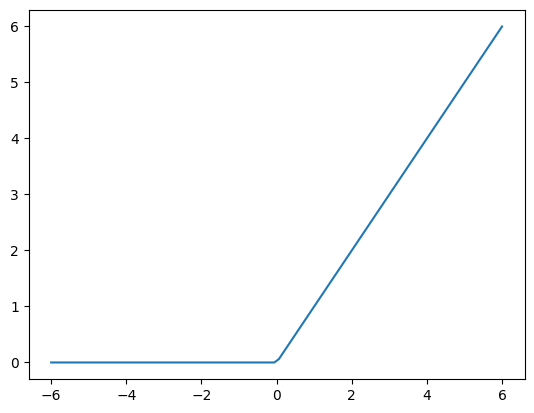

In [41]:
x = np.linspace(-6, 6, 100)

# convert from Var to ndarray
def Var_to_nparray(x):
  y = np.zeros((len(x),len(x[0])))
  for i in range(len(x)):
    for j in range(len(x[0])):
      y[i,j] = x[i][j].v
  return y

# define 1-1 network with weight = 1 and relu activation
NN = [ DenseLayer(1, 1, lambda x: x.relu(), initializer = ConstantInitializer(1.0)) ]
y = Var_to_nparray(forward(nparray_to_Var(x), NN))

#y = Var_to_nparray(relu(nparray_to_Var(x)))
plt.plot(x,y)

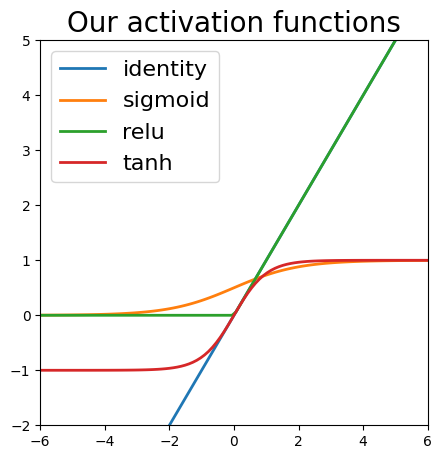

In [42]:
# Testing all activation layers

x = np.linspace(-6, 6, 100)
units = {
    "identity": lambda x: x.identity(),
    "sigmoid": lambda x: x.sigmoid(),
    "relu": lambda x: x.relu(),
    "tanh": lambda x: x.tanh()
}

plt.figure(figsize=(5, 5))
[plt.plot(x, Var_to_nparray(forward(nparray_to_Var(x), [DenseLayer(1, 1, unit, initializer = ConstantInitializer(1.0))]) ), label=unit_name, lw=2) for unit_name, unit in units.items()] # unit(nparray_to_Var(x))), label=unit_name, lw=2) for unit_name, unit in units.items()]
plt.legend(loc=2, fontsize=16)
plt.title('Our activation functions', fontsize=20)
plt.ylim([-2, 5])
plt.xlim([-6, 6])
plt.show()

# Advanced initialization schemes

If we are not careful with initialization, the signals we propagate forward ($a^{(l)}$, $l=1,\ldots,L$) and backward ($\delta^l$, $l=L,L-1,\ldots,1$) can blow up or shrink to zero. A statistical analysis of the variance of the signals for different activation functions can be found in these two papers: [Glorot initialization](http://proceedings.mlr.press/v9/glorot10a/glorot10a.pdf) and [He initialization](https://arxiv.org/pdf/1502.01852v1.pdf).

The result of the analyses are proposals for how to make the initialization such that the variance of the signals (forward and backward) are kept approxmimatly constant when propagating from layer to layer. The exact expressions depend upon the non-linear activation function used. In Glorot initialization, the aim is to keep both the forward and backward variances constant whereas He only aims at keeping the variance in the forward pass constant.

We define $n_{in}$ and $n_{out}$ as the number of input units and output units of a particular layer.

The Glorot initialization has the form:

$$w_{ij} \sim N \bigg( 0, \, \frac{2 \alpha }{n_{in} + n_{out}} \bigg) \ . $$

where $N(\mu,\sigma^2)$ is a Gaussian distribution with mean $\mu$ and variance $\sigma^2$ and $\alpha$ is a parameter that depends upon the activation function used. For $\tanh$, $\alpha=1$ and for Rectified Linear Unit (ReLU) activations, $\alpha=2$. (It is also possible to use a uniform distribution for initialization, see [this blog post](https://mmuratarat.github.io/2019-02-25/xavier-glorot-he-weight-init).)

The He initialization is very similar

$$w_{ij} \sim N \bigg( 0, \, \frac{\alpha}{n_{in}} \bigg) \ . $$

## Exercise i) Glorot and He initialization

Using the Initializer class, implement functions that implement Glorot and He

Explain briefly how you would test numerically that these initializations have the sought after property. Hint: See plots in Glorot paper.

Comment: If you want to be more advanced then try to make a universal initializer taking both the activation function and type (Glorot or He) as argument.

In [20]:
## Glorot
def DenseLayer_Glorot_tanh(n_in: int, n_out: int):
  std = math.sqrt(2/(n_in+n_out)) # <- replace with proper initialization
  return DenseLayer(n_in, n_out, lambda x: x.tanh(), initializer = NormalInitializer(std=std))

## He
def DenseLayer_He_relu(n_in: int, n_out: int):
  std = math.sqrt(2/n_in) # <- replace with proper initialization
  return DenseLayer(n_in, n_out, lambda x: x.relu(), initializer = NormalInitializer(std=std))

In [44]:
initializer = NormalInitializer(std=math.sqrt(1/25))
number_array = []
for number in initializer.init_weights(20,30)[0]:
    number_array.append(number.v)
# print(number_array[0])
mean_k = sum(number_array) / len(number_array); print(mean_k)
std_k = (sum((x - mean_k) ** 2 for x in number_array) / len(number_array)) ** 0.5;print(std_k)

-0.03269982491244694

0.12971608665649084

In [45]:
k = []
k = Var_to_nparray(DenseLayer_Glorot_tanh(100,100).weights)
mean_k = np.mean(k);print(mean_k)
var_k = np.var(k);print(var_k)



-0.00023951172662421593

0.010115848254172412

In [46]:
k = []
for var in DenseLayer_He_relu(100,100).weights[0]:
    k.append(var.v)
mean_k = sum(k) / len(k); print(mean_k)
var_k = (sum((x - mean_k) ** 2 for x in k) / len(k)) ;print(var_k)



-0.012138545865041261

0.017349377568403428

# How you test numerically? --Question

## Exercise j) Forward pass unit test

Write a bit of code to make a unit test that the forward pass works. This can be done by defining a simple network with for example all weights equal to one (using the ConstantInitializer method) and identity activation functions.

Hints: Use the [assert](https://www.w3schools.com/python/ref_keyword_assert.asp), the nparray_to_Var and the Var_to_nparray commands.

In [47]:
def Var_to_nparray(x):
  y = np.zeros((len(x),len(x[0])))
  for i in range(len(x)):
    for j in range(len(x[0])):
      y[i,j] = x[i][j].v
  return y

def nparray_to_Var(x):
  if x.ndim==1:
    y = [[Var(float(x[i]))] for i in range(x.shape[0])] # always work with list of list
  else:
    y = [[Var(float(x[i,j])) for j in range(x.shape[1])] for i in range(x.shape[0])]
  return y


#### Simple testing

In [48]:
input = [Var(5.0)]
test_layer = DenseLayer(1, 1, lambda x: x.identity(),initializer=ConstantInitializer())
out = test_layer.forward(input)[0]
assert out.v == 5
assert out.grad == 0

input = [Var(-1.0)]
test_layer = DenseLayer(1, 1, lambda x: x.relu(),initializer=ConstantInitializer())
out = test_layer.forward(input)[0]
assert out.v == 0
assert out.grad == 0


In [49]:

NN = [
    DenseLayer(1, 5, lambda x: x.identity(),initializer=ConstantInitializer()),
    DenseLayer(5, 1, lambda x: x.identity(),initializer=ConstantInitializer())
]

def forward(input, network):

  def forward_single(x, network):
    for layer in network:
        x = layer.forward(x)
    return x

  output = [forward_single(input[n], network) for n in range(len(input))]
  return output

output_1 = forward(x_train, NN)




In [50]:
assert all(a[0].v == b[0].v for a, b in zip(x_train, output_1))

In [51]:
assert len(x_train) == len(output_1)
assert len(x_train[0]) == len(output_1[0])

# Loss functions

We are only missing a loss function to we need to define a loss function and its derivative with respect to the output of the neural network $y$

In [38]:
## y is the output of neral network, t is true value 
def squared_loss(t, y):

  # add check that sizes agree

  def squared_loss_single(t, y):
    Loss = Var(0.0)
    for i in range(len(t)): # sum over outputs
      Loss += (t[i]-y[i]) ** 2
    return Loss

  Loss = Var(0.0)
  for n in range(len(t)): # sum over training data
    Loss += squared_loss_single(t[n],y[n])
  return Loss

## Exercise k) Implement cross entropy loss

Insert code below to implement cross-entropy loss for general dimensionality of $t$. Use a logits formulation:
$$
\rm{Loss} = - \sum_i t_i \, log \, p_i
$$
with $p$ given by the the softmax function in terms of the logits $h$:
$$
p_i = \frac{\exp(h_i)}{\sum_{i'} \exp(h_{i'})} .
$$
Inserting $p$ in the expression for the loss gives
$$
\rm{Loss} = - \sum_i t_i h_i + \rm{LogSumExp}(h) \ ,
$$
where
$$
\rm{LogSumExp}(h) = \log \sum_i \exp h_i \ .
$$
This is true for $t$ being a one-hot vector.

Call the function to convince yourself it works.

In practice you want to implement a [numerically stable](https://leimao.github.io/blog/LogSumExp/) version of LogSumExp. But we will not bother about that here.

Help: You can add these methods in the Var class:

    def exp(self):
        return Var(exp(self.v), lambda: [(self, exp(self.v))])
    
    def log(self):
        return Var(log(self.v), lambda: [(self, self.v ** -1)])

In [53]:

NN = [
    DenseLayer(1, 5, lambda x: x.relu()),
    DenseLayer(5, 1, lambda x: x.identity())
]

def forward(input, network):

  def forward_single(x, network):
    for layer in network:
        x = layer.forward(x)
    return x

  output = [forward_single(input[n], network) for n in range(len(input))]
  return output

output_1 = forward(x_train, NN)

In [54]:
#t is the true label(y_train), h is the output of neral network from the last layer(output1)
def cross_entropy_loss(t, h):
    
    assert len(t) == len(h)
    
    def logsumExp(h):
        logsumExp_term = Var(0.0)
        exp_h_list = [var.exp() for var in sum(h, [])]
        for i in range(len(exp_h_list)):
            logsumExp_term += exp_h_list[i]
        return logsumExp_term
    
    def sum_t_h(h,t):
        sum_t_h_term = Var(0.0)
        mul_t_h_list = [h*t for h,t in zip(sum(h, []),sum(t, []))]
        for i in range(len(mul_t_h_list)):
            sum_t_h_term+= mul_t_h_list[i]
        return sum_t_h_term
    
    Loss = logsumExp(h) - sum_t_h(t,h)
    return Loss 

In [55]:
cross_entropy_loss(y_train,output_1) 

Var(v=104.0123, grad=0.0000)

# Backward pass

Now the magic happens! We get the calculation of the gradients for free. Just do:

In [56]:
NN = [
    DenseLayer(1, 7, lambda x: x.relu()),
    DenseLayer(7, 1, lambda x: x.identity())
]

output = forward(x_train, NN)

Loss = squared_loss(y_train,output)
Loss.backward()

and the gradients will be calculated:

In [57]:
[print('Layer', i, '\n', NN[i]) for i in range(len(NN))]

Layer 0 
 DenseLayer(weights=[Var(v=-0.0040, grad=5.9807), Var(v=0.1406, grad=0.0000), Var(v=0.0298, grad=0.0000), 
Var(v=0.0247, grad=0.0000), Var(v=0.1728, grad=0.0000), Var(v=-0.0201, grad=0.0000), Var(v=-0.0747, grad=0.0000)], 
bias=[Var(v=0.0000, grad=-5.6917), Var(v=0.0000, grad=0.0000), Var(v=0.0000, grad=0.0000), Var(v=0.0000, 
grad=0.0000), Var(v=0.0000, grad=0.0000), Var(v=0.0000, grad=0.0000), Var(v=0.0000, 
grad=0.0000)],act_fun=x.relu()),)

Layer 1 
 DenseLayer(weights=[Var(v=-0.0645, grad=0.3722)], bias=[Var(v=0.0000, grad=-0.1668)],act_fun=x.identity()))

[None, None]

# Backward pass unit test

Above we used finite differences to test that Nanograd is actually doing what it is supposed to do. We can in principle try the same for the neural network. But we will trust that the test above is enough.

# Training and validation

We are ready to train some neural networks!

We initialize again:

In [58]:
NN = [
    DenseLayer_He_relu(1,5),
    DenseLayer_He_relu(5,10),
    DenseLayer_Glorot_tanh(10,1)
]

output = forward(x_train, NN)
Loss = squared_loss(y_train,output)
Loss.backward()


and make an update:

We introduce a help function parameters to have a handle in all parameters in the network.

In [59]:
print('Network before update:')
[print('Layer', i, '\n', NN[i]) for i in range(len(NN))]

def parameters(network):
  params = []
  for layer in range(len(network)):
    params += network[layer].parameters() ##parameters get weight and bias
  return params

def update_parameters(params, learning_rate=0.01):
  for p in params:
    p.v -= learning_rate*p.grad #own weight.v change with own weight.grad

def zero_gradients(params):
  for p in params:
    p.grad = 0.0

update_parameters(parameters(NN))

print('\nNetwork after update:')
[print('Layer', i, '\n', NN[i]) for i in range(len(NN))]

zero_gradients(parameters(NN))

print('\nNetwork after zeroing gradients:')
[print('Layer', i, '\n', NN[i]) for i in range(len(NN))]

Network before update:

Layer 0 
 DenseLayer(weights=[Var(v=2.4018, grad=0.0000), Var(v=-1.1951, grad=0.0000), Var(v=0.6339, grad=0.0000), 
Var(v=-1.6971, grad=0.0000), Var(v=0.8087, grad=0.0000)], bias=[Var(v=0.0000, grad=0.0000), Var(v=0.0000, 
grad=0.0000), Var(v=0.0000, grad=0.0000), Var(v=0.0000, grad=0.0000), Var(v=0.0000, grad=0.0000)],act_fun=x.relu(),
initializer = NormalInitializer(std=std)))

Layer 1 
 DenseLayer(weights=[Var(v=-0.6636, grad=0.0000), Var(v=-0.2173, grad=0.0000), Var(v=0.5760, grad=0.0000), 
Var(v=0.2778, grad=0.0000), Var(v=-1.0349, grad=0.0000), Var(v=-0.5033, grad=0.0000), Var(v=0.2272, grad=0.0000), 
Var(v=-0.3106, grad=0.0000), Var(v=-1.0123, grad=0.0000), Var(v=-0.4985, grad=0.0000)], bias=[Var(v=0.0000, 
grad=0.0000), Var(v=0.0000, grad=0.0000), Var(v=0.0000, grad=0.0000), Var(v=0.0000, grad=0.0000), Var(v=0.0000, 
grad=0.0000), Var(v=0.0000, grad=0.0000), Var(v=0.0000, grad=0.0000), Var(v=0.0000, grad=0.0000), Var(v=0.0000, 
grad=0.0000), Var(v=0.0000, grad=0.0000)],act_fun=x.relu(), initializer = NormalInitializer(std=std)))

Layer 2 
 DenseLayer(weights=[Var(v=-0.1648, grad=0.0000)], bias=[Var(v=0.0000, grad=-0.0000)],act_fun=x.tanh(), initializer
= NormalInitializer(std=std)))

Network after update:

...

Network after zeroing gradients:

Layer 0 
 DenseLayer(weights=[Var(v=2.4018, grad=0.0000), Var(v=-1.1951, grad=0.0000), Var(v=0.6339, grad=0.0000), 
Var(v=-1.6971, grad=0.0000), Var(v=0.8087, grad=0.0000)], bias=[Var(v=0.0000, grad=0.0000), Var(v=0.0000, 
grad=0.0000), Var(v=0.0000, grad=0.0000), Var(v=0.0000, grad=0.0000), Var(v=0.0000, grad=0.0000)],act_fun=x.relu(),
initializer = NormalInitializer(std=std)))

Layer 1 
 DenseLayer(weights=[Var(v=-0.6636, grad=0.0000), Var(v=-0.2173, grad=0.0000), Var(v=0.5760, grad=0.0000), 
Var(v=0.2778, grad=0.0000), Var(v=-1.0349, grad=0.0000), Var(v=-0.5033, grad=0.0000), Var(v=0.2272, grad=0.0000), 
Var(v=-0.3106, grad=0.0000), Var(v=-1.0123, grad=0.0000), Var(v=-0.4985, grad=0.0000)], bias=[Var(v=0.0000, 
grad=0.0000), Var(v=0.0000, grad=0.0000), Var(v=0.0000, grad=0.0000), Var(v=0.0000, grad=0.0000), Var(v=0.0000, 
grad=0.0000), Var(v=0.0000, grad=0.0000), Var(v=0.0000, grad=0.0000), Var(v=0.0000, grad=0.0000), Var(v=0.0000, 
grad=0.0000), Var(v=0.0000, grad=0.0000)],act_fun=x.relu(), initializer = NormalInitializer(std=std)))

Layer 2 
 DenseLayer(weights=[Var(v=-0.1648, grad=0.0000)], bias=[Var(v=0.0000, grad=0.0000)],act_fun=x.tanh(), initializer 
= NormalInitializer(std=std)))

[None, None, None]

In [60]:
x_train_copy,y_train_copy,x_validation_copy,y_validation_copy = x_train,y_train,x_validation,y_validation


In [ ]:
# # Initialize an arbitrary neural network
NN = [
    DenseLayer(1, 5, lambda x: x.relu()),
    DenseLayer(5, 1, lambda x: x.identity())
]

#Recommended hyper-parameters for 3-D:
# NN = [
#    DenseLayer(3, 16, lambda x: x.relu()),
#    DenseLayer(16, 1, lambda x: x.identity())
# ]


### Notice that, when we switch from tanh to relu activation, we decrease the learning rate. This is due the stability of the gradients
## of the activation functions.

In [ ]:
# Initialize training hyperparameters
EPOCHS = 200
LEARN_R = 2e-3


DenseLayer(weights=[Var(v=-0.0789, grad=0.0000), Var(v=-0.0508, grad=0.0000), Var(v=0.0436, grad=0.0000), Var(v=0.1324, grad=0.0000), Var(v=-0.0658, grad=0.0000)], bias=[Var(v=0.0000, grad=0.0000), Var(v=0.0000, grad=0.0000), Var(v=0.0000, grad=0.0000), Var(v=0.0000, grad=0.0000), Var(v=0.0000, grad=0.0000)],act_fun=x.relu()))

In [64]:
train_loss = []
val_loss = []

for e in range(EPOCHS):

    # Forward pass and loss computation
    Loss = squared_loss(y_train_copy, forward(x_train_copy, NN))

    # Backward pass
    Loss.backward()

    # gradient descent update
    update_parameters(parameters(NN), LEARN_R)
    zero_gradients(parameters(NN))

    # Training loss
    train_loss.append(Loss.v)

    # Validation
    Loss_validation = squared_loss(y_validation_copy, forward(x_validation_copy, NN))
    val_loss.append(Loss_validation.v)

    if e%10==0:
        print("{:4d}".format(e),
              "({:5.2f}%)".format(e/EPOCHS*100),
              "Train loss: {:4.3f} \t Validation loss: {:4.3f}".format(train_loss[-1], val_loss[-1]))



OverflowError: (34, 'Numerical result out of range')

In [ ]:
plt.plot(range(len(train_loss)), train_loss);
plt.plot(range(len(val_loss)), val_loss);

# Testing

We have kept the calculation of the test error separate in order to emphasize that you should not use the test set in optimization.

In [ ]:
output_test = forward(x_test, NN)

In [ ]:
y_test_np = Var_to_nparray(y_test)
plt.scatter(y_test_np, Var_to_nparray(output_test));
plt.plot([np.min(y_test_np), np.max(y_test_np)], [np.min(y_test_np), np.max(y_test_np)], color='k');
plt.xlabel("y");
plt.ylabel("$\hat{y}$");
plt.title("Model prediction vs real in the test set, the close to the line the better")
plt.grid(True);
plt.axis('equal');
plt.tight_layout();

Loss_test = squared_loss(y_test, forward(x_test, NN))

print("Test loss:  {:4.3f}".format(Loss_test.v))

In [ ]:
x_test_np = Var_to_nparray(x_test)
x_train_np = Var_to_nparray(x_train)
y_train_np = Var_to_nparray(y_train)
if D1:
    plt.scatter(x_train_np, y_train_np, label="train data");
    plt.scatter(x_test_np, Var_to_nparray(output_test), label="test prediction");
    plt.scatter(x_test_np, y_test_np, label="test data");
    plt.legend();
    plt.xlabel("x");
    plt.ylabel("y");
else:
    plt.scatter(x_train_np[:,1], y_train, label="train data");
    plt.scatter(x_test_np[:,1], Var_to_nparray(output_test), label="test data prediction");
    plt.scatter(x_test_np[:,1], y_test_np, label="test data");
    plt.legend();
    plt.xlabel("x");
    plt.ylabel("y");

## Exercise l) Show overfitting, underfitting and just right fitting

Vary the architecture and other things to show clear signs of overfitting (=training loss significantly lower than test loss) and underfitting (=not fitting enoung to training data so that test performance is also hurt).

See also if you can get a good compromise which leads to a low validation loss.

For this problem do you see any big difference between validation and test loss? The answer here will probably be no. Discuss cases where it is important to keep the two separate.

_Insert written answer here._


In [ ]:
# Insert your code for getting overfitting, underfitting and just right fitting

# Next steps - classification

It is straight forward to extend what we have done to classification.

For numerical stability it is better to make softmax and cross-entropy as one function so we write the cross entropy loss as a function of the logits we talked about last week.

Next week we will see how to perform classification in PyTorch.

## Exercise m) optional - Implement backpropagation for classification

Should be possible with very few lines of code. :-)

In [ ]:
# Just add code.

## Exercise n) optional - Introduce a NeuralNetwork class

The functions we applied on the neural network (parameters, update_parameters and zero_gradients) can more naturally be included as methods in a NeuralNetwork class. Make such a class and modify the code to use it.

In [ ]:
# just add some code